## Etapa 1: Buscador de Imágenes por Similitud


### 1. Preparación del Entorno

In [19]:
#Importación de librerías, seteo de entorno y procesador (CPU / GPU)
import os
import sys
import uuid
from typing import Any, Dict, List, Optional, Tuple
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from dotenv import load_dotenv
from sklearn.preprocessing import LabelEncoder


load_dotenv(dotenv_path=".env.docker.example")

import sys
sys.path.append(os.path.abspath('./src'))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


Para poder interactuar y almacenar las representaciones vectoriales (embedings) de los perros de forma persistente, instanciamos el cliente de la base de datos vectorial PGVector utilizando credenciales cargadas desde el entorno de desarrollo (.env).

In [2]:
#Instanciamos la base de datos vectorial
store = PgVectorEmbeddingStore(
    dbname=os.getenv("POSTGRES_DB","dogs"),
    user=os.getenv("POSTGRES_USER", "dogs_user"),
    password=os.getenv("POSTGRES_PASSWORD", "dogs_pass"),
    host=os.getenv("POSTGRES_ALT_HOST", "localhost"),
    port=int(os.getenv("POSTGRES_PORT", "5432")),
    embedding_dim=int(os.getenv("EMBEDDING_DIM", 1280))
)

store.truncate()

In [3]:
#Definimos las variables de entorno
DATASET_PATH = os.getenv("DATASET_PATH")
DATA_PATH = os.getenv("DATA_PATH")
IMAGE_SIZE = int(os.getenv("IMAGE_SIZE", "224"))
EMBEDDING_DIM = int(os.getenv("EMBEDDING_DIM","1280"))
TOP_K = int(os.getenv("TOP_K", "10"))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "32"))

## 2. Instanciación del Modelo 

In [4]:
#Instanciamos el modelo de EfficientNet_B0 con sus respectivos pesos, lo ponemos en modo evaluación
weights = models.EfficientNet_B0_Weights.DEFAULT
base_model = models.efficientnet_b0(weights=weights)

class EfficientNetEmbedding(nn.Module):
    """
    Modelo personalizado para extraer embeddings de EfficientNet-B0.
     - Se eliminan las capas de clasificación y se mantiene la parte de extracción de características.
     - El método forward devuelve un vector de características de tamaño 1280.
    """
    def __init__(self, base_model):
        super().__init__()
        self.features = base_model.features
        self.pool = base_model.avgpool

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

model = EfficientNetEmbedding(base_model)
model.eval() 

EfficientNetEmbedding(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNo

## 3. Preprocesamiento

In [5]:
#Definimos el pipeline de preprocesamiento
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [6]:
#Instanciamos los dataloaders
train_dir = f'{DATASET_PATH}/train'
train_dataset = datasets.ImageFolder(root=train_dir, transform=preprocess)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_dir = f'{DATASET_PATH}/test'
test_dataset = datasets.ImageFolder(root=test_dir, transform=preprocess)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

## 4. Extracción de Embeddings

Generamos una función para facilitar la extracción de los embeddings

In [7]:
def extraer_embeddings(loader: DataLoader, split_name: str, model: torch.nn.Module, device: str, persistencia: bool = False, store: Optional[PgVectorEmbeddingStore] = None) -> Tuple[int, List[Dict[str, Any]]]:
    """
    Extrae embeddings de un DataLoader, los normaliza y opcionalmente los persiste en pgvector.
    
    Argumentos:
        loader: El DataLoader con los datos a procesar.
        split_name (str): El nombre del dataset.
        model: El modelo de PyTorch a utilizr.
        device: 'cuda' o 'cpu'.
        persistencia (bool): Si es True, guarda en la base de datos.
        store: La instancia de PgVectorEmbeddingStore (requerido si persistencia=True).
    
    Funcionamiento:
        - Itera sobre los batches del DataLoader.
        - Para cada batch, mueve las imágenes al dispositivo, extrae los embeddings, los normaliza y los convierte a numpy.
        - Para cada imagen en el batch, obtiene la ruta completa, la clase, genera un ID único y crea un registro.
        - Si persistencia es True, guarda el registro en la base de datos usando store.append_batch().
            - Este proceso se hace en batches para evitar crear una conexión nueva a la base de datos cada vez que persistimos un registro. (Ahorro de ~7 min en la extracción total).
        - Si persistencia es False, acumula los registros en una lista para su posterior uso.
    """
    idx_global = 0  
    registros_no_persistidos = []
    dataset = loader.dataset 
    print(f"Iniciando extracción para el set de '{split_name}'...")
    model.eval()

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Procesando batches ({split_name})"):
            
            images = images.to(device)
            
            embeddings = model(images)
            embeddings_norm = F.normalize(embeddings, p=2, dim=1)
            embeddings_np = embeddings_norm.cpu().numpy()
            batch_registros = []
            for i in range(len(images)):

                ruta_completa, class_idx = dataset.samples[idx_global]
                ruta_normalizada = ruta_completa.replace('\\', '/')
                breed = dataset.classes[class_idx]
                id_unico = str(uuid.uuid4())
                embedding_lista = embeddings_np[i].tolist()
                if persistencia and store is not None:
                    record = EmbeddingRecord(
                        id_imagen=id_unico,
                        path=ruta_normalizada,    
                        breed=breed,           
                        embedding=embedding_lista, 
                        metadata={"split": split_name}
                    )
                    batch_registros.append(record)
                else:
                    registro = {
                        "id_imagen": id_unico,
                        "ruta": ruta_normalizada,
                        "breed": breed,          
                        "embedding": embedding_lista, 
                        "metadata": {"split": split_name}
                    }
                    registros_no_persistidos.append(registro)

                idx_global += 1

            
            if persistencia and store is not None and batch_registros:
                store.append_batch(batch_registros)

    print(f"Extracción para '{split_name}' completada.")
    return idx_global, registros_no_persistidos

In [8]:
cont_train, _ = extraer_embeddings(train_loader, "train", model, device, persistencia=True, store=store)

Iniciando extracción para el set de 'train'...


Procesando batches (train): 100%|██████████| 249/249 [03:49<00:00,  1.09it/s]


Extracción para 'train' completada.


In [9]:
cont_test, embeddings_test = extraer_embeddings(test_loader, "test", model, device, persistencia=False, store=None)

Iniciando extracción para el set de 'test'...


Procesando batches (test):   0%|          | 0/22 [00:00<?, ?it/s]

Procesando batches (test): 100%|██████████| 22/22 [00:24<00:00,  1.11s/it]


Extracción para 'test' completada.


In [10]:
print("Imágenes de Train procesadas:", cont_train)
print("Imágenes de Test procesadas:", cont_test)

Imágenes de Train procesadas: 7946
Imágenes de Test procesadas: 700


In [11]:
print(f"Embedding de Test 0: {embeddings_test[0]}")

Embedding de Test 0: {'id_imagen': 'b733bafd-9666-49ed-a9f5-d65aa7f739c7', 'ruta': 'data/dataset/test/Afghan/01.jpg', 'breed': 'Afghan', 'embedding': [0.036877937614917755, -0.0025603948161005974, -0.01027168333530426, 0.0036312041338533163, -0.016716301441192627, -0.013669640757143497, 0.019545378163456917, -0.007606069091707468, -0.004555617459118366, 0.019221294671297073, -0.015007694251835346, 0.020970970392227173, -0.0007580429082736373, -0.014559932053089142, -0.013201387599110603, -0.014422590844333172, -0.015296020545065403, -0.0030586670618504286, -0.015211783349514008, -0.01829518936574459, -0.007239931263029575, 0.01760278083384037, -0.006260275840759277, -0.013588197529315948, -0.013197296299040318, 0.10493236035108566, -0.008398274891078472, 0.04151725396513939, -0.015064453706145287, -0.013130868785083294, -0.016465485095977783, 0.06476955860853195, -0.012271268293261528, -0.014014264568686485, 0.0018316198838874698, -0.012510702013969421, -0.009771366603672504, -0.013607

## 5. Cálculo de NDCG@10

In [17]:
def calcular_dcg(relevancias):
    """
    Calcula el Discounted Cumulative Gain.
    relevancias: lista o array de 0s y 1s.
    """
    relevancias = np.array(relevancias)
    descuentos = np.log2(np.arange(len(relevancias)) + 2)
    return np.sum(relevancias / descuentos)

def calculate_ndcg(relevancias):
    """
    Calcula el NDCG asumiendo que los únicos documentos relevantes
    en el universo son los que lograste recuperar en esta lista (relevancia binaria).
    """
    dcg = calcular_dcg(relevancias)
    
    relevancias_ideales = sorted(relevancias, reverse=True)
    idcg = calcular_dcg(relevancias_ideales)
    
    if idcg == 0:
        return 0.0
        
    return dcg / idcg

In [18]:
ndcg_scores_totales = []
ndcg_por_raza = {}

for item in embeddings_test:
    # Definimos el vector_busqueda y la raza real
    vector_busqueda = item['embedding'] 
    raza_esperada = item['breed']       
    
    # Hacemos la consulta a la base de datos para recuperar los 10 más cercanos
    resultados_top_10 = store.alt_search(query=vector_busqueda, k=10)
    relevancia = [1 if rec.breed == raza_esperada else 0 for rec in resultados_top_10]
    
    # Calculamos el NDCG de esta búsqueda
    score_ndcg = calculate_ndcg(relevancia)
    
    # Guardamos para el promedio general
    ndcg_scores_totales.append(score_ndcg)
    
    # Guardamos para el promedio por raza
    if raza_esperada not in ndcg_por_raza:
        ndcg_por_raza[raza_esperada] = []
    ndcg_por_raza[raza_esperada].append(score_ndcg)

ndcg_promedio = np.mean(ndcg_scores_totales)
print(f"NDCG@10 Promedio evaluando {len(embeddings_test)} imágenes: {ndcg_promedio:.4f}\n")

datos_agrupados = []
for raza, scores in ndcg_por_raza.items():
    datos_agrupados.append({
        'Raza': raza,
        'NDCG_Promedio': np.mean(scores),
        'Cantidad_Tests': len(scores) 
    })

df_metricas = pd.DataFrame(datos_agrupados)

# Ordenamos de peor a mejor para que los peores queden abajo en el primer top
df_metricas = df_metricas.sort_values(by='NDCG_Promedio', ascending=True)

# Mostrar los extremos por consola
print("---\t TOP 10 PEORES CLASES \t---")
print(df_metricas.head(10).to_string(index=False))
print("\n---\t TOP 10 MEJORES CLASES \t---")
print(df_metricas.tail(10).to_string(index=False))

NDCG@10 Promedio evaluando 700 imágenes: 0.9718

---	 TOP 10 PEORES CLASES 	---
             Raza  NDCG_Promedio  Cantidad_Tests
          Bulldog       0.720953              10
         Malinois       0.843319              10
   Boston Terrier       0.867846              10
 American Spaniel       0.868703              10
         Cockapoo       0.877912              10
      Labradoodle       0.888430              10
American Hairless       0.898445              10
       Great Dane       0.905209              10
         Shih-Tzu       0.922275              10
        Shiba Inu       0.940062              10

---	 TOP 10 MEJORES CLASES 	---
            Raza  NDCG_Promedio  Cantidad_Tests
         Clumber            1.0              10
        Bermaise            1.0              10
    Bichon Frise            1.0              10
      Bloodhound            1.0              10
      Rottweiler            1.0              10
   Saint Bernard            1.0              10
 Irish Wolfh

La métricas de NDCG@10 evalúa que tan bien el sistema ordena los vecinos más relevantes dentro de las primeras 10 posiciones, penalizando los casos en donde lso resultados relevantes aparecen en las posiciones más bajas.
Logramos un NDCG@10 promedio de 0,9718, muy cercano a 1, lo cual nos indica en promedio una alta calidad en el ordenamiento de lso resultados recuperados por parte de nuestro modelo 

## 6. Visualización con TSNE

In [ ]:
registros = store.all()
embeddings_array = np.array([rec.embedding for rec in registros])
etiquetas_raza = [rec.breed for rec in registros]
ids_imagenes = [rec.id_imagen for rec in registros]

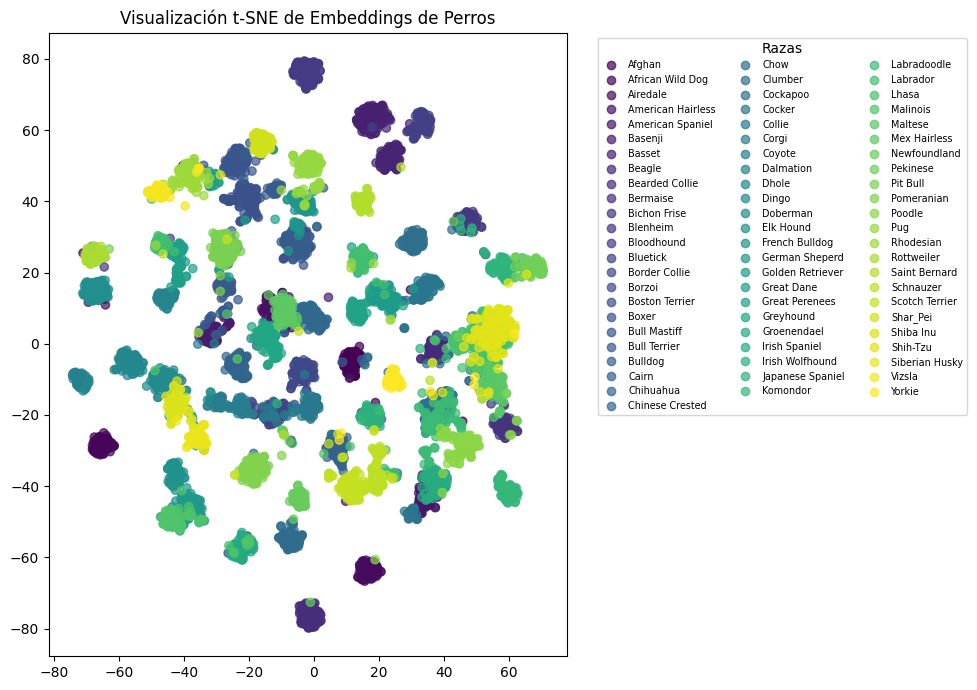

In [ ]:
# Convertimos las etiquetas de texto (razas) a números
# Esto le asigna un número único a cada raza
le = LabelEncoder()
etiquetas_numericas = le.fit_transform(etiquetas_raza)

# Aplicamos t-SNE
tsne = TSNE(n_components=2, perplexity=40,random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_array)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=etiquetas_numericas, 
    cmap='viridis', 
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements(num=len(le.classes_))[0],
    labels=le.classes_.tolist(), 
    title="Razas",
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    ncol=3,       
    fontsize='x-small'  
)

plt.title("Visualización t-SNE de Embeddings de Perros")
plt.tight_layout()
plt.show()

La visualización mediante TSNE nos permite observar que no existe una gran separación entre los embeddings de las diferentes razas lo cual nos permite intuir que al momento de usarlos para mostrar los 10 vecinos más cernaos del embedding dado es muy probable que aparezcan razas que no corresponden a la de la imagen de entrada y esta se va a deber a la morfología similar de los perros y quizá también a como se generaron los embeddings.